In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [36]:
medicare_fraud = pd.read_csv(
    "../data/raw/TRAIN1.csv",
    encoding='utf-8-sig'
)

medicare_fraud.columns = medicare_fraud.columns.str.replace(
    'ï»¿',
    ''
)

In [37]:
medicare_fraud.head()

,Provider,PotentialFraud,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,WhetherDead
0,PRV51001,No,BENE11727,CLM733300,17-12-2009,17-12-2009,20,PHY383007,NaN,PHY383007,...,1,0,0,0,0,0,300,110,80,0
1,PRV51001,No,BENE24646,CLM372475,22-05-2009,23-05-2009,700,PHY405682,NaN,PHY402512,...,1,1,0,1,0,0,720,10,67,0
2,PRV51001,No,BENE31617,CLM748221,28-12-2009,28-12-2009,900,PHY345302,NaN,NaN,...,1,0,1,0,0,0,1380,370,76,0
3,PRV51001,No,BENE32715,CLM272936,29-03-2009,30-03-2009,500,PHY318842,PHY392882,NaN,...,1,0,0,0,2020,1068,6700,2700,74,0
4,PRV51001,No,BENE36012,CLM58316,04-07-2009,08-07-2009,36000,PHY340163,NaN,NaN,...,1,0,0,1,36000,1068,3520,140,69,0


In [38]:
medicare_fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 558211 entries, 0 to 558210
Data columns (total 58 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Provider                         558211 non-null  str    
 1   PotentialFraud                   558211 non-null  str    
 2   BeneID                           558211 non-null  str    
 3   ClaimID                          558211 non-null  str    
 4   ClaimStartDt                     558211 non-null  str    
 5   ClaimEndDt                       558211 non-null  str    
 6   InscClaimAmtReimbursed           558211 non-null  int64  
 7   AttendingPhysician               556703 non-null  str    
 8   OperatingPhysician               114447 non-null  str    
 9   OtherPhysician                   199736 non-null  str    
 10  ClmDiagnosisCode_1               547758 non-null  str    
 11  ClmDiagnosisCode_2               362605 non-null  str    
 12  ClmDiagnosisC

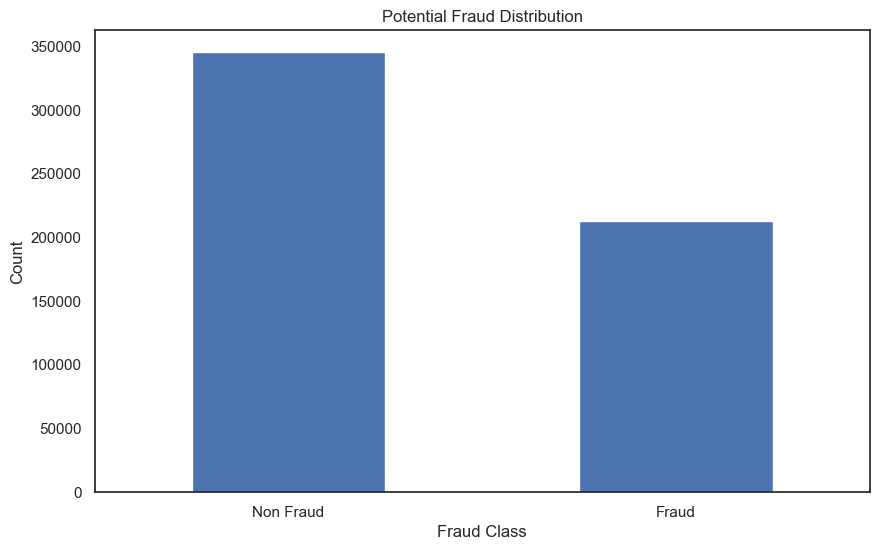

In [39]:
sns.set_style(
    'white',
    rc={'figure.figsize':(12,8)}
)

count_classes = medicare_fraud[
    'PotentialFraud'
].value_counts(
    sort=True
)

LABELS = ["Non Fraud", "Fraud"]

count_classes.plot(
    kind='bar',
    rot=0,
    figsize=(10,6)
)

plt.title(
    "Potential Fraud Distribution"
)

plt.xticks(range(2), LABELS)

plt.xlabel("Fraud Class")

plt.ylabel("Count")

plt.savefig(
    "../outputs/plots/fraud_distribution.png",
    bbox_inches='tight'
)

plt.show()

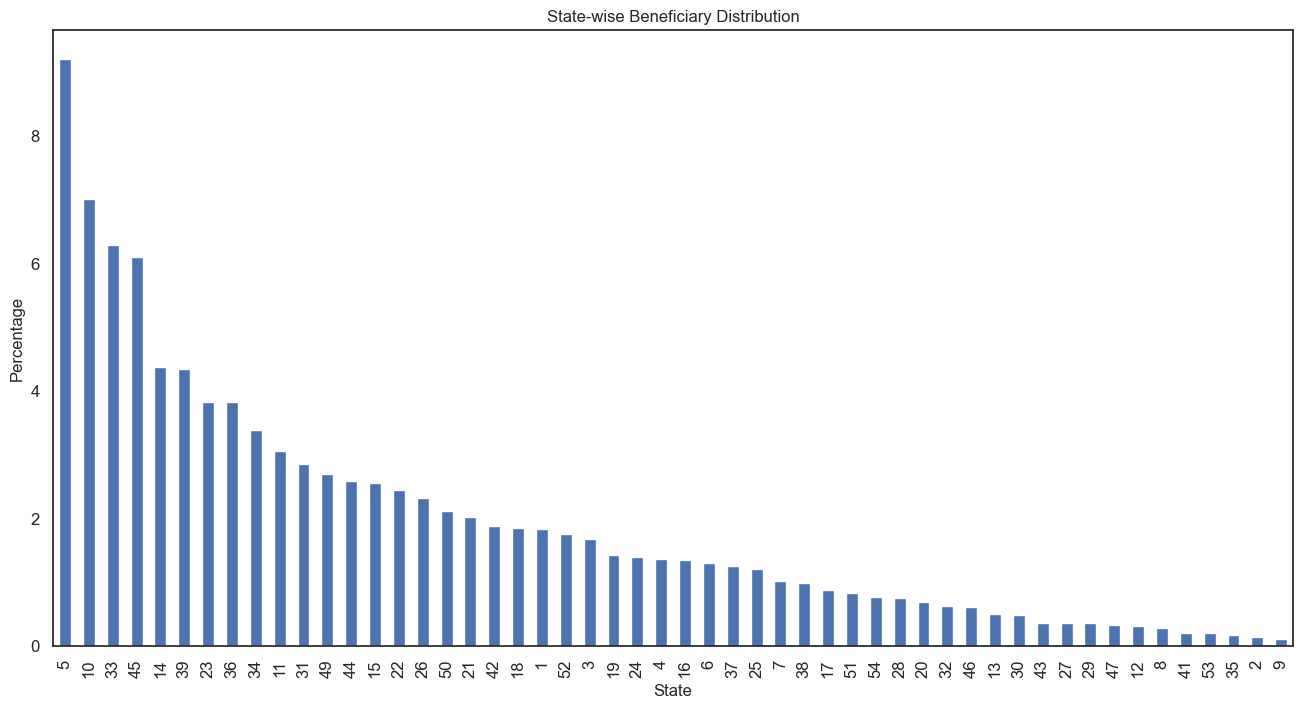

In [40]:
count_states = medicare_fraud[
    'State'
].value_counts(
    sort=True
)

(count_states * 100 / len(medicare_fraud)).plot(
    kind='bar',
    figsize=(16,8),
    fontsize=12
)

plt.title(
    "State-wise Beneficiary Distribution"
)

plt.xlabel("State")

plt.ylabel("Percentage")

plt.savefig(
    "../outputs/plots/state_distribution.png",
    bbox_inches='tight'
)

plt.show()

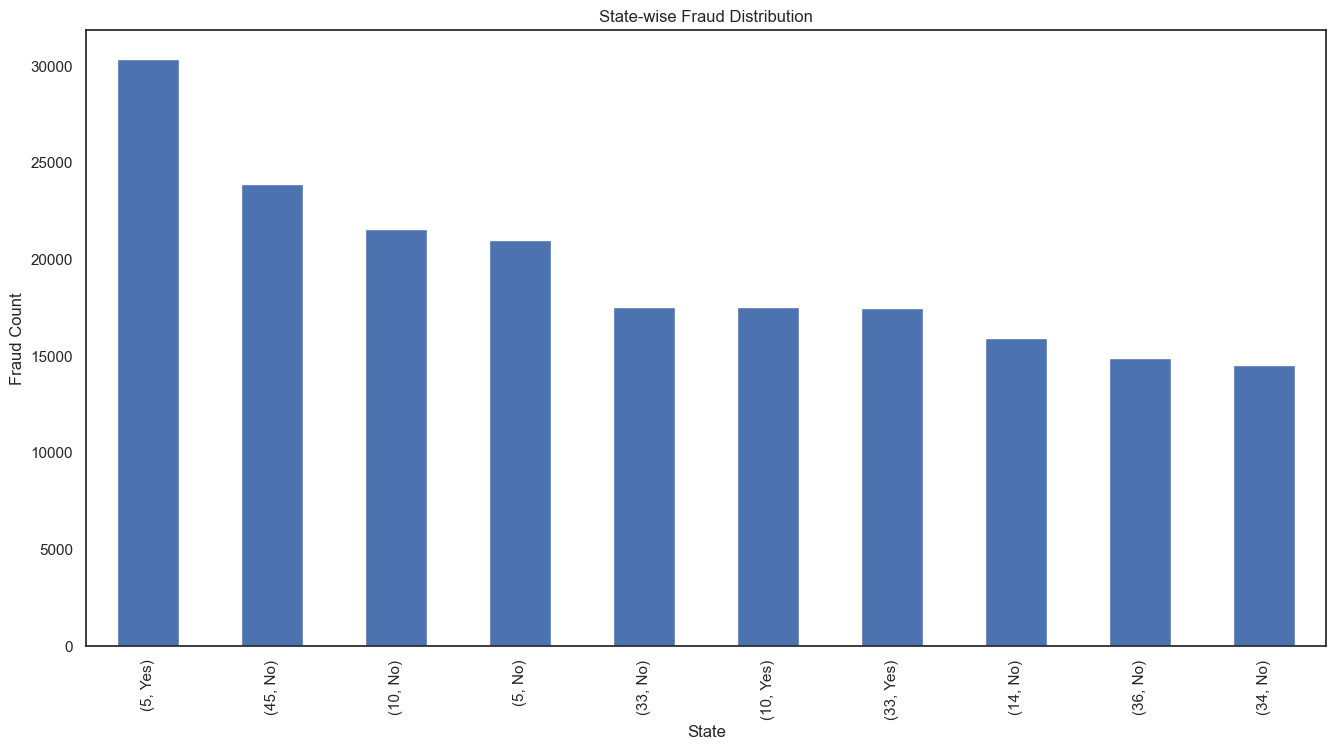

In [41]:
medicare_fraud.groupby(
    ['State','PotentialFraud']
)['PotentialFraud'].count().sort_values(
    ascending=False
)[:10].plot.bar(
    figsize=(16,8)
)

plt.title(
    "State-wise Fraud Distribution"
)

plt.xlabel("State")

plt.ylabel("Fraud Count")

plt.savefig(
    "../outputs/plots/state_fraud.png",
    bbox_inches='tight'
)

plt.show()

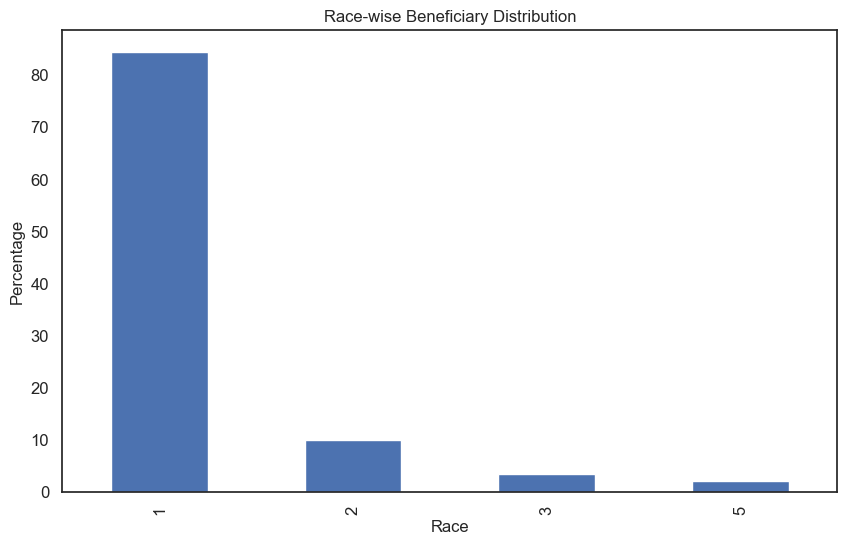

In [42]:
count_race = medicare_fraud[
    'Race'
].value_counts(
    sort=True
)

(count_race * 100 / len(medicare_fraud)).plot(
    kind='bar',
    figsize=(10,6),
    fontsize=12
)

plt.title(
    "Race-wise Beneficiary Distribution"
)

plt.xlabel("Race")

plt.ylabel("Percentage")

plt.savefig(
    "../outputs/plots/race_distribution.png",
    bbox_inches='tight'
)

plt.show()

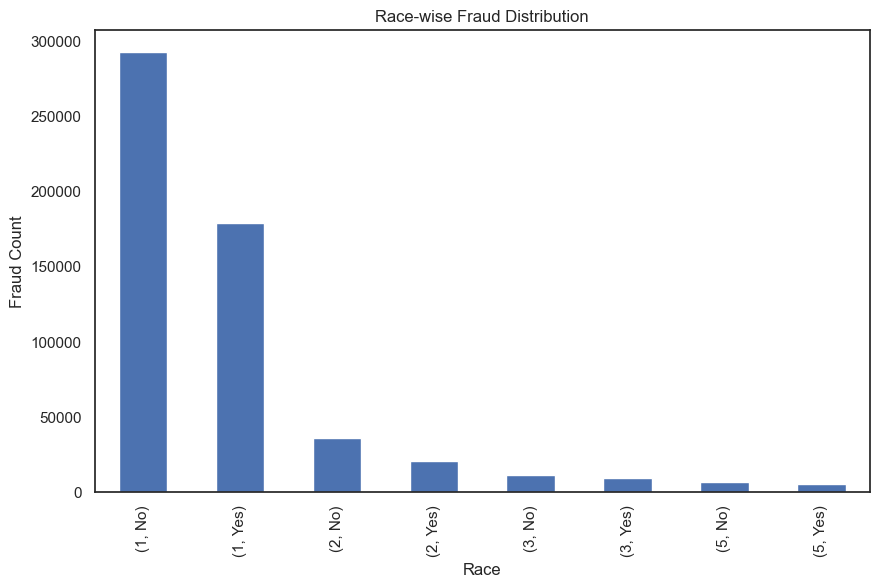

In [43]:
medicare_fraud.groupby(
    ['Race','PotentialFraud']
)['PotentialFraud'].count().sort_values(
    ascending=False
).plot.bar(
    figsize=(10,6)
)

plt.title(
    "Race-wise Fraud Distribution"
)

plt.xlabel("Race")

plt.ylabel("Fraud Count")

plt.savefig(
    "../outputs/plots/race_fraud.png",
    bbox_inches='tight'
)

plt.show()

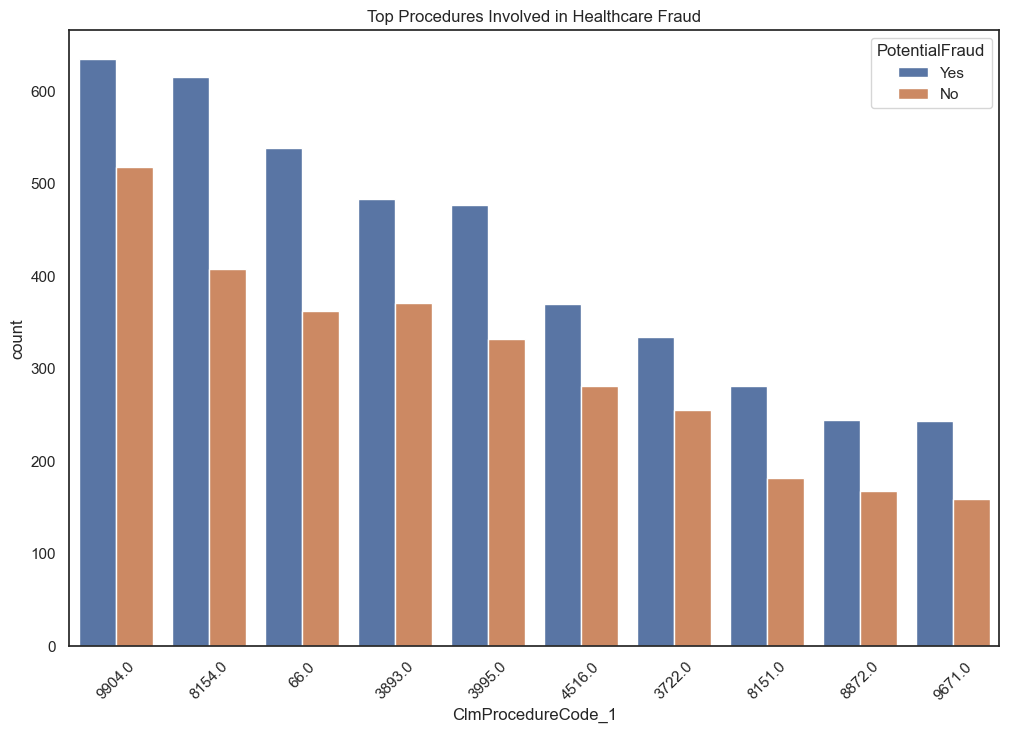

In [44]:
sns.set(
    rc={'figure.figsize':(12,8)},
    style='white'
)

sns.countplot(
    x='ClmProcedureCode_1',
    hue='PotentialFraud',
    data=medicare_fraud,
    order=medicare_fraud.ClmProcedureCode_1.value_counts().iloc[:10].index
)

plt.title(
    'Top Procedures Involved in Healthcare Fraud'
)

plt.xticks(rotation=45)

plt.savefig(
    "../outputs/plots/top_procedures.png",
    bbox_inches='tight'
)

plt.show()

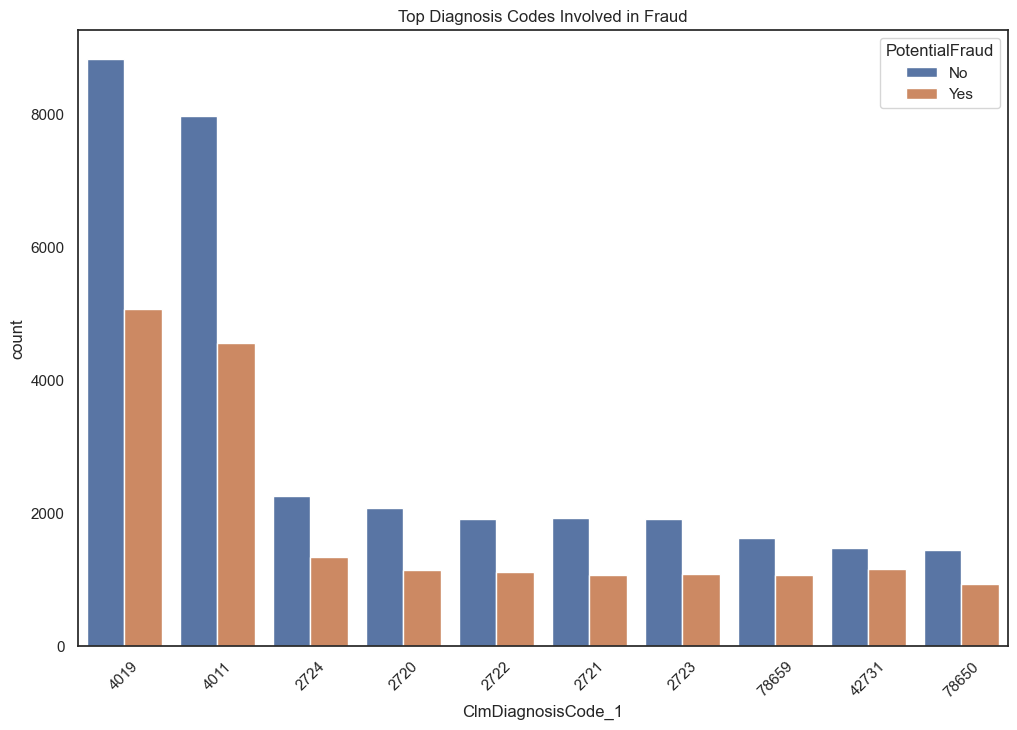

In [45]:
sns.countplot(
    x='ClmDiagnosisCode_1',
    hue='PotentialFraud',
    data=medicare_fraud,
    order=medicare_fraud.ClmDiagnosisCode_1.value_counts().iloc[:10].index
)

plt.title(
    'Top Diagnosis Codes Involved in Fraud'
)

plt.xticks(rotation=45)

plt.savefig(
    "../outputs/plots/top_diagnosis.png",
    bbox_inches='tight'
)

plt.show()

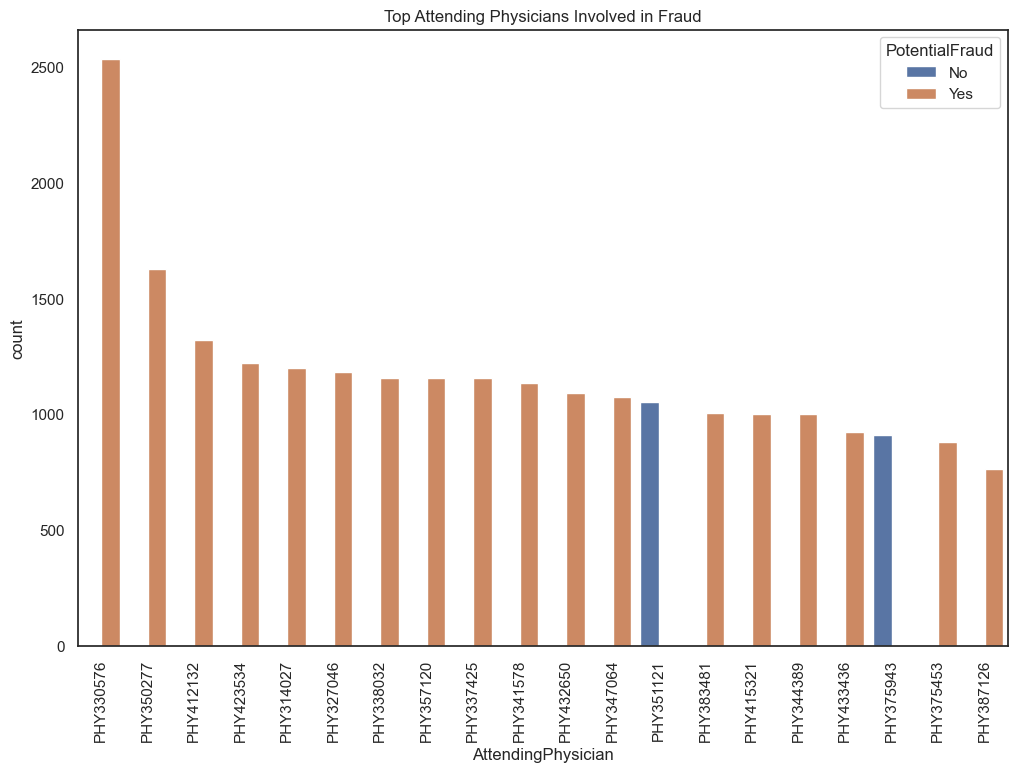

In [46]:
sns.countplot(
    x='AttendingPhysician',
    hue='PotentialFraud',
    data=medicare_fraud,
    order=medicare_fraud.AttendingPhysician.value_counts().iloc[:20].index
)

plt.title(
    'Top Attending Physicians Involved in Fraud'
)

plt.xticks(rotation=90)

plt.savefig(
    "../outputs/plots/top_physicians.png",
    bbox_inches='tight'
)

plt.show()

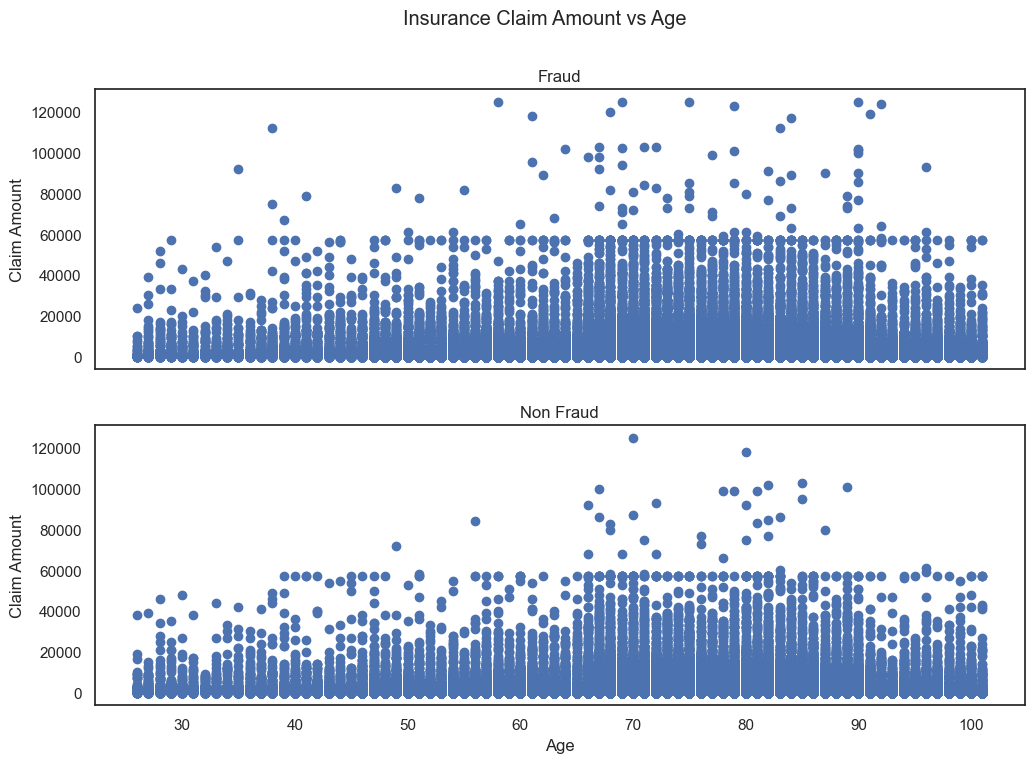

In [47]:
f, (ax1, ax2) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(12,8)
)

f.suptitle(
    'Insurance Claim Amount vs Age'
)

ax1.scatter(
    medicare_fraud[
        medicare_fraud.PotentialFraud=='Yes'
    ].Age,

    medicare_fraud[
        medicare_fraud.PotentialFraud=='Yes'
    ].InscClaimAmtReimbursed
)

ax1.set_title('Fraud')

ax1.set_ylabel('Claim Amount')

ax2.scatter(
    medicare_fraud[
        medicare_fraud.PotentialFraud=='No'
    ].Age,

    medicare_fraud[
        medicare_fraud.PotentialFraud=='No'
    ].InscClaimAmtReimbursed
)

ax2.set_title('Non Fraud')

ax2.set_xlabel('Age')

ax2.set_ylabel('Claim Amount')

plt.savefig(
    "../outputs/plots/age_vs_claim.png",
    bbox_inches='tight'
)

plt.show()

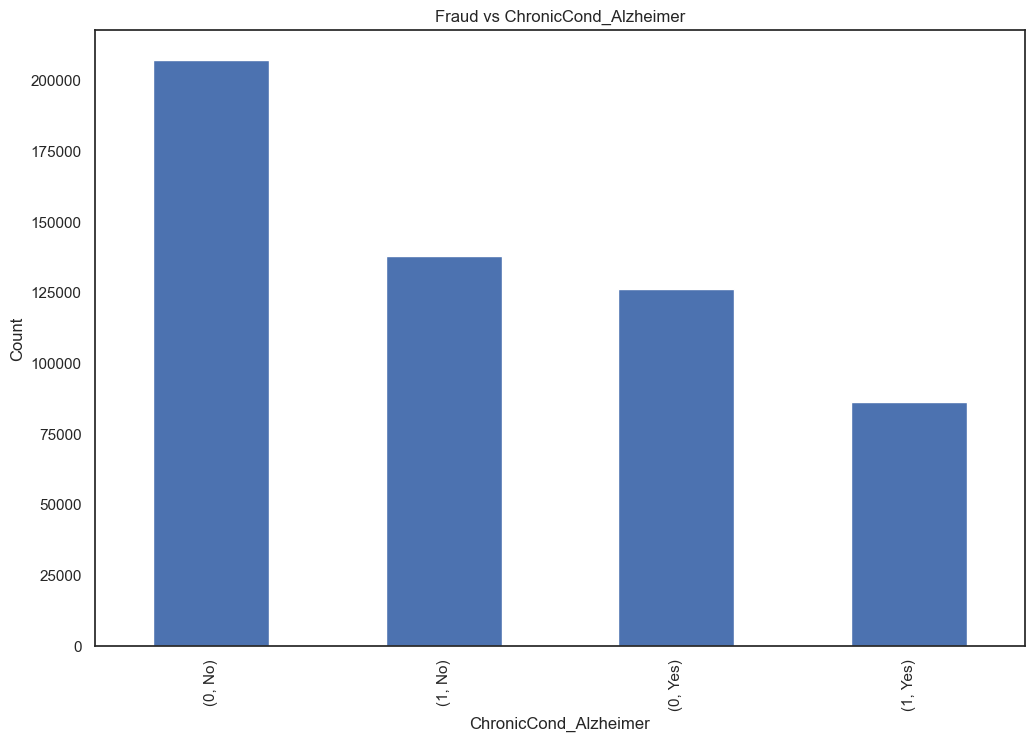

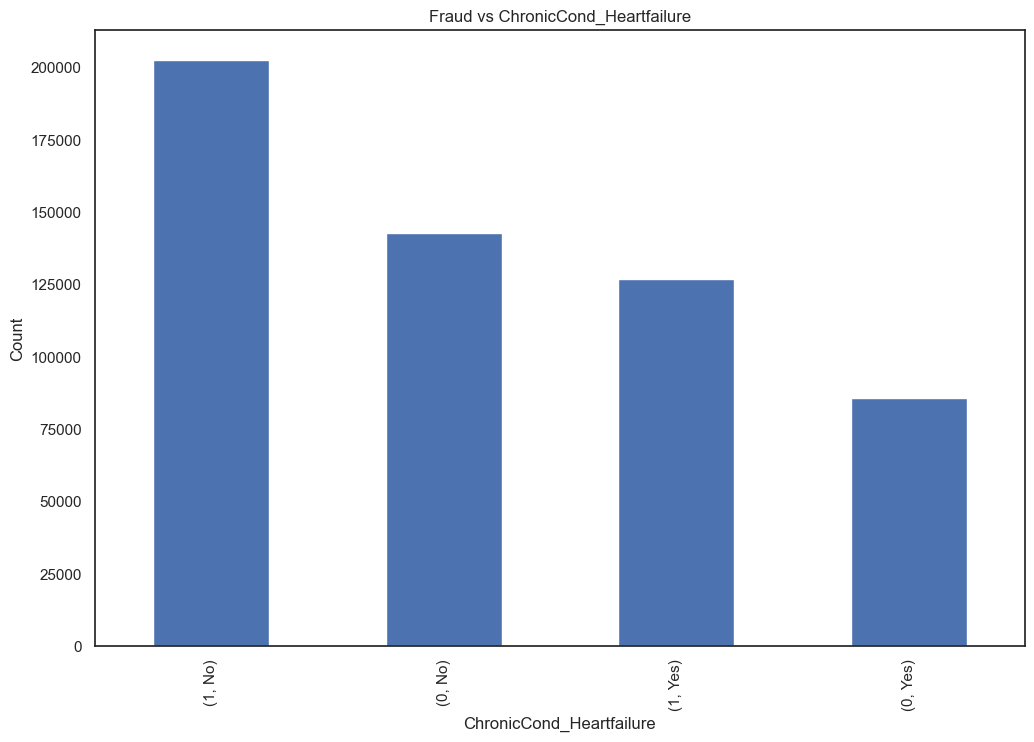

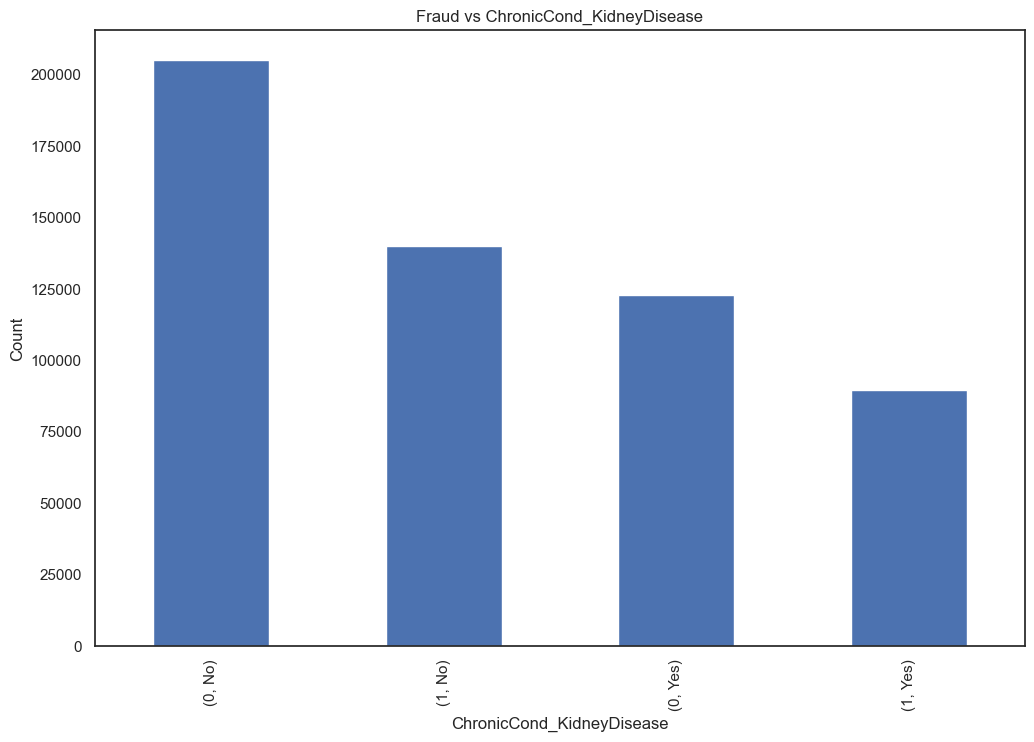

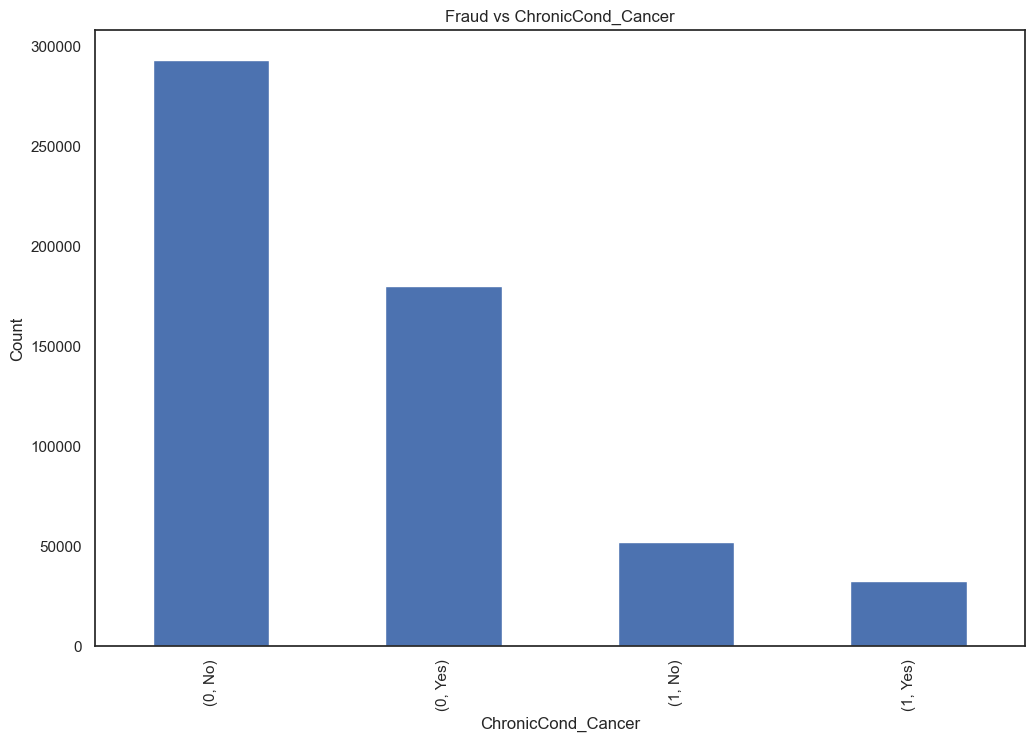

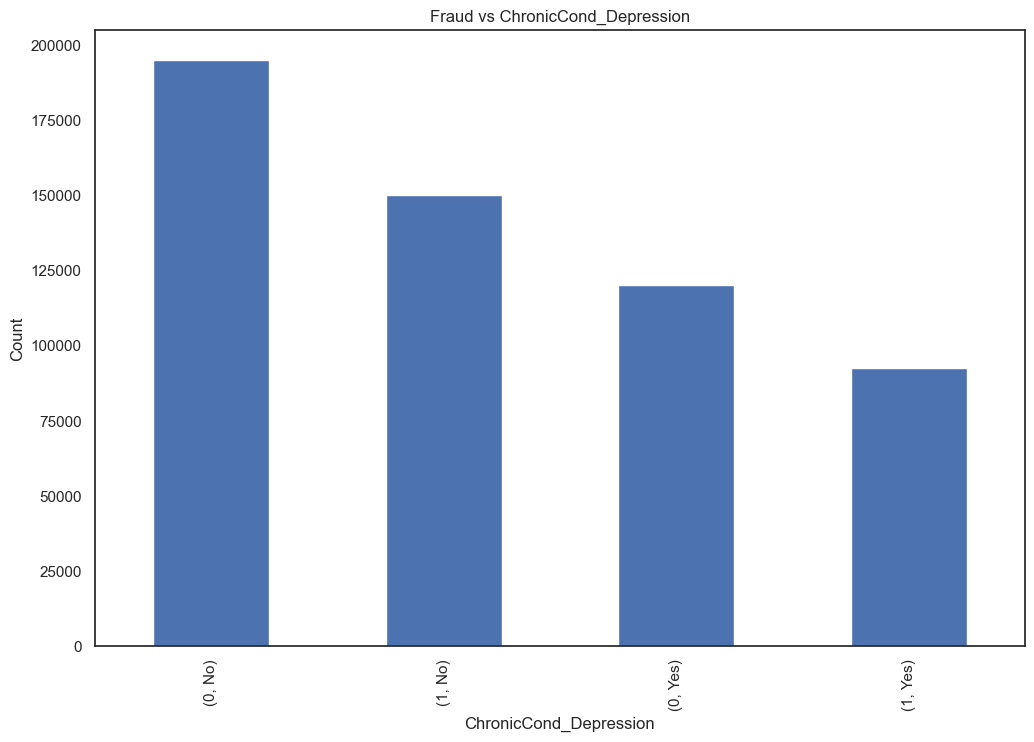

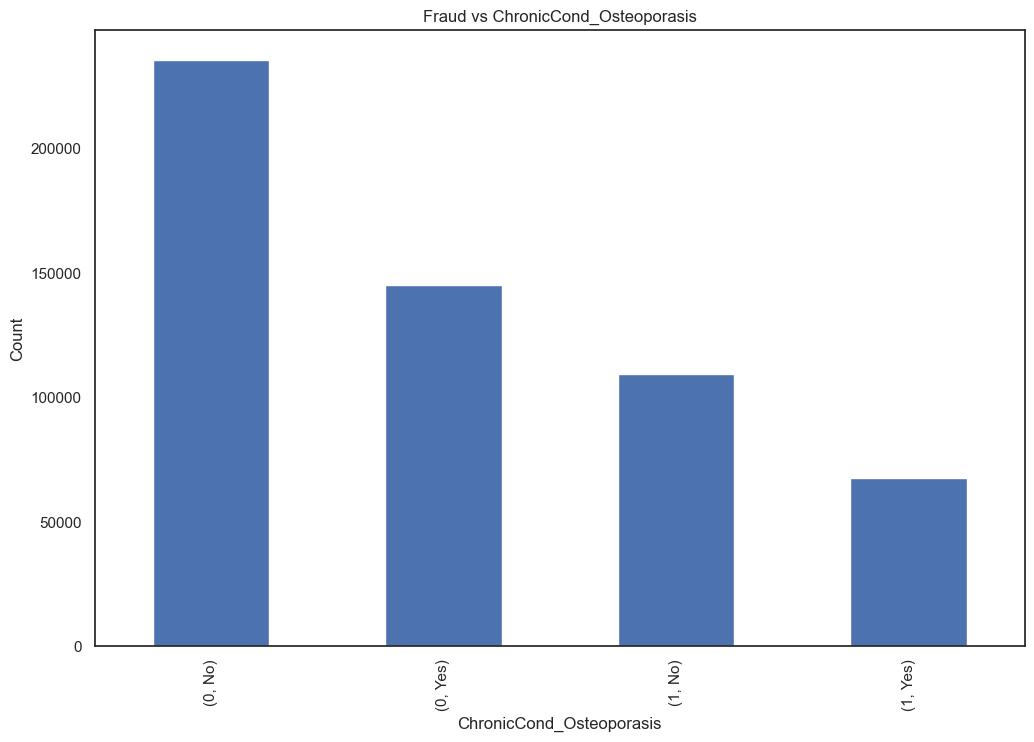

In [48]:
conditions = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Cancer',
    'ChronicCond_Depression',
    'ChronicCond_Osteoporasis'
]

for condition in conditions:

    medicare_fraud.groupby(
        [condition, 'PotentialFraud']
    )['PotentialFraud'].count().sort_values(
        ascending=False
    ).plot.bar(figsize=(12,8))

    plt.title(
        f"Fraud vs {condition}"
    )

    plt.xlabel(condition)

    plt.ylabel("Count")

    plt.savefig(
        f"../outputs/plots/{condition}.png",
        bbox_inches='tight'
    )

    plt.show()